## Setup

In [22]:
# %pip install transformers torch matplotlib

import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer, logging

logging.set_verbosity_error()
logging.disable_progress_bar()

In [23]:
_CACHE = {}

def load(model_name="gpt2"):
    if model_name not in _CACHE:
        tok = AutoTokenizer.from_pretrained(model_name, token=False)
        mdl = AutoModelForCausalLM.from_pretrained(
            model_name, token=False, attn_implementation="eager")
        mdl.eval()
        _CACHE[model_name] = (tok, mdl)
    return _CACHE[model_name]

In [24]:
@torch.no_grad()
def sweep_probs(model, base_embeds, attn_mask, changed_index,
                v_start, v_end, alphas, chunk=32):
    """Batched interpolation sweep.

    Blends base_embeds[0, changed_index] from v_start to v_end across alphas and
    returns (n_alphas, vocab) softmax probabilities at the final position.

    Chunked because HF returns logits for every position: a 101-step sweep over a
    7-token prompt is 101 x 7 x 50257 floats if you do it in one shot.
    """
    out = []
    for i in range(0, len(alphas), chunk):
        a = alphas[i:i + chunk]
        n = len(a)
        E = base_embeds.repeat(n, 1, 1)
        E[:, changed_index, :] = (1 - a)[:, None] * v_start + a[:, None] * v_end
        logits = model(inputs_embeds=E, attention_mask=attn_mask.repeat(n, 1)).logits
        out.append(logits[:, -1, :].softmax(-1))
    return torch.cat(out)

## The experiment

In [44]:
def nullify_attention(phrase, changed_index, target_word, model_name="gpt2",
                      n_steps=101, top_k=5, thresh=0.02, chunk=32, show=True):
    """Run the same alpha sweep twice: once normally, once with the morphed token
    masked out of attention. Plot both side by side.

    The two panels plot different token sets on different y-scales, on purpose.
    P_blind is a constant function of alpha, and its top tokens are almost never
    the same ones the intact model predicts — the blindfolded model is answering
    a different question ("I ... [void] ... very") and answering it badly.

    changed_index must be an interior position. Position 0 is its own only key, so
    masking it makes softmax NaN. The final position feeds the logits through its own
    residual stream, so masking that one wouldn't flatten anything.
    """
    tokenizer, model = load(model_name=model_name)
    emb = model.get_input_embeddings()

    inputs = tokenizer(phrase, return_tensors="pt")
    ids, attn = inputs["input_ids"], inputs["attention_mask"]
    seq_len = ids.shape[1]
    print("tokens:", list(enumerate(tokenizer.convert_ids_to_tokens(ids[0]))))

    if not 1 <= changed_index <= seq_len - 2:
        raise ValueError(
            f"changed_index must be in 1..{seq_len - 2} for this prompt, got {changed_index}. "
            "Position 0 has no other key to fall back on; the last position reaches the "
            "logits without needing attention at all."
        )

    base = emb(ids).detach()
    v_start = base[0, changed_index, :].clone()

    t_ids = tokenizer.encode(" " + target_word)
    if len(t_ids) != 1:
        print(f"warning: {target_word!r} -> {len(t_ids)} tokens "
              f"{tokenizer.convert_ids_to_tokens(t_ids)}, using the first")
    v_end = emb.weight[t_ids[0]].detach().clone()

    morph_word = tokenizer.decode(ids[0][changed_index]).strip()
    alphas = torch.linspace(0, 1, n_steps)

    # the entire intervention: one column of the attention matrix, gone
    blind = attn.clone()
    blind[0, changed_index] = 0

    P_open = sweep_probs(model, base, attn, changed_index, v_start, v_end, alphas, chunk)
    P_blind = sweep_probs(model, base, blind, changed_index, v_start, v_end, alphas, chunk)

    drift = (P_blind - P_blind[0:1]).abs().max().item()
    print(f"\nblindfolded: largest change in any token's probability across the "
          f"whole sweep = {drift:.3e}")
    print("  no attention path means alpha has no route to the output. Expect 0.0.")

    top1 = P_open.argmax(-1)
    transitions = [(alphas[i].item(),
                    tokenizer.decode(top1[i - 1]).strip(),
                    tokenizer.decode(top1[i]).strip())
                   for i in range(1, n_steps) if top1[i] != top1[i - 1]]

    print(f"\nmorphing {morph_word!r} -> {target_word!r} at position {changed_index}")
    print(f"  attention intact: {len(transitions)} transition(s)")
    for a, frm, to in transitions:
        print(f"    alpha={a:.2f}  {frm!r} -> {to!r}")

    # left panel: what the intact model predicts, filtered by thresh
    cand = torch.topk(P_open, top_k, dim=-1).indices.flatten().unique().tolist()
    keep_open = [t for t in cand if P_open[:, t].max().item() >= thresh]
    keep_open = sorted(keep_open, key=lambda t: -P_open[:, t].max().item())[:8]
    keep_open = sorted(keep_open, key=lambda t: int(P_open[:, t].argmax()))

    # right panel: P_blind is constant in alpha, so row 0's top-k IS every row's
    # top-k. No thresh — these probabilities are small precisely because the
    # blindfolded model has no idea, and that's worth seeing rather than filtering out.
    keep_blind = P_blind[0].topk(top_k).indices.tolist()

    blind_top5 = [(tokenizer.decode(t).strip(), round(P_blind[0, t].item(), 4))
                  for t in keep_blind]
    print(f"  blindfolded:      {blind_top5}")
    print(f"                    identical at all {n_steps} alphas")

    if show:
        colors = plt.get_cmap("tab10").colors
        x = alphas.numpy()
        fig, axes = plt.subplots(1, 2, figsize=(13, 5))   # no sharey: scales differ ~10x
        panels = [
            (axes[0], P_open, keep_open, "attention intact", True),
            (axes[1], P_blind, keep_blind,
             f"position {changed_index} ({morph_word!r}) masked   "
             f"— max change {drift:.1e}", False),
        ]
        for ax, P, ks, title, marks in panels:
            for k, t in enumerate(ks):
                ax.plot(x, P[:, t].numpy(), lw=2, color=colors[k % 10],
                        label=repr(tokenizer.convert_ids_to_tokens([t])[0]))
            if marks:
                for a, *_ in transitions:
                    ax.axvline(a, color="red", ls="--", lw=1)
            ax.set_title(title, fontsize=12)
            ax.set_xlabel(f"alpha   (0 = {morph_word!r},  1 = {target_word!r})")
            ax.set_ylabel("probability of next token")
            ax.set_xlim(0, 1)
            ax.set_ylim(0, None)
            ax.grid(alpha=0.2)
            ax.legend(fontsize=9, loc="upper right")
        plt.tight_layout()
        plt.show()

    return {"alphas": alphas, "P_open": P_open, "P_blind": P_blind,
            "transitions": transitions,
            "keep_open": keep_open, "keep_blind": keep_blind,
            "morph_word": morph_word, "target_word": target_word,
            "v_start": v_start, "v_end": v_end, "tokenizer": tokenizer}

## Run it

Same prompt as the interpolation notebook. Left panel is what you already have. Right panel is
the same sweep with one column of the attention matrix removed.

tokens: [(0, 'I'), (1, 'Ġlove'), (2, 'Ġschool'), (3, 'Ġbecause'), (4, 'Ġit'), (5, "'s"), (6, 'Ġvery')]

blindfolded: largest change in any token's probability across the whole sweep = 0.000e+00
  no attention path means alpha has no route to the output. Expect 0.0.

morphing 'love' -> 'hate' at position 1
  attention intact: 2 transition(s)
    alpha=0.59  'fun' -> ','
    alpha=0.62  ',' -> 'hard'
  blindfolded:      [('hard', 0.0754), ('important', 0.0623), ('difficult', 0.0387), ('easy', 0.0351), (',', 0.0344)]
                    identical at all 101 alphas


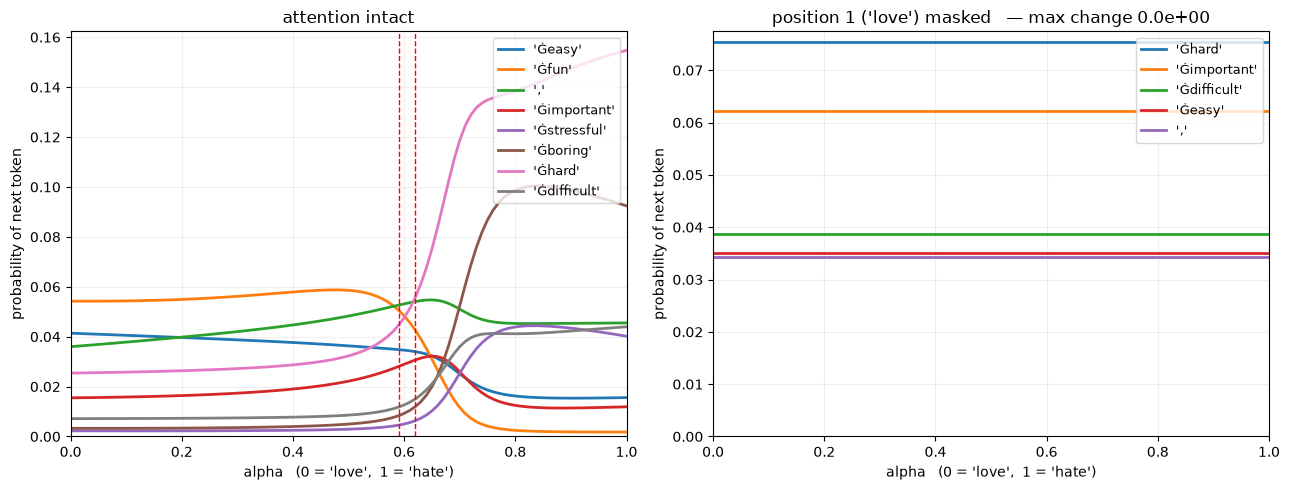

In [45]:
r1 = nullify_attention("I love school because it's very", changed_index=1, target_word="hate")

tokens: [(0, 'I'), (1, 'Ġlike'), (2, 'Ġpizza'), (3, ','), (4, 'Ġand'), (5, 'ĠI'), (6, 'Ġalways'), (7, 'Ġget'), (8, 'Ġit'), (9, 'Ġwith'), (10, 'Ġa'), (11, 'Ġlot'), (12, 'Ġof')]

blindfolded: largest change in any token's probability across the whole sweep = 0.000e+00
  no attention path means alpha has no route to the output. Expect 0.0.

morphing 'pizza' -> 'salad' at position 2
  attention intact: 3 transition(s)
    alpha=0.06  'people' -> 'different'
    alpha=0.33  'different' -> 'cheese'
    alpha=0.43  'cheese' -> 'vegetables'
  blindfolded:      [('people', 0.1406), ('the', 0.0341), ('my', 0.0323), ('different', 0.0255), ('them', 0.0251)]
                    identical at all 101 alphas


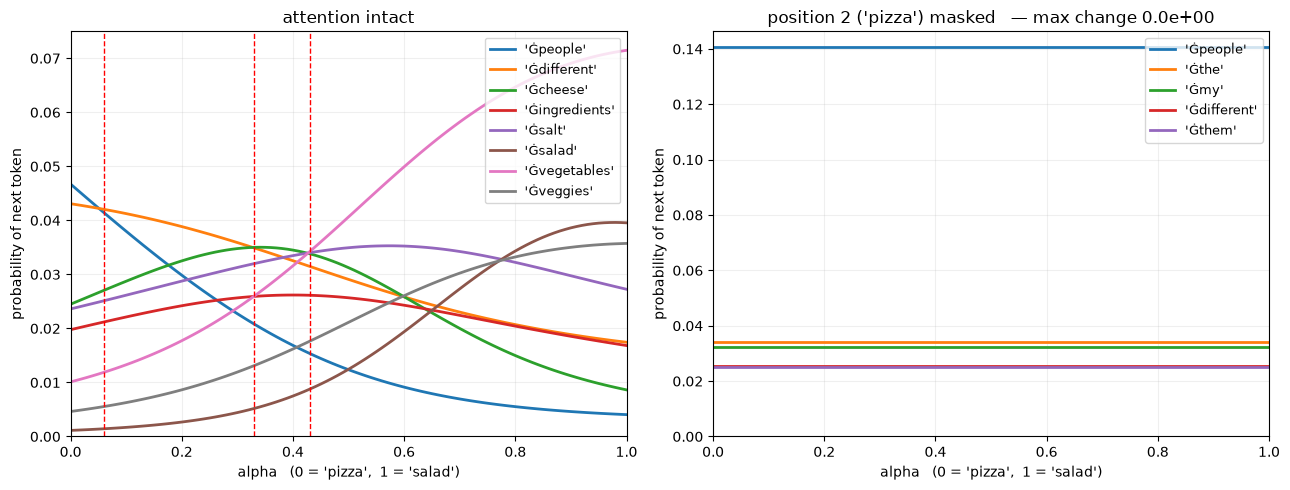

In [50]:
r2 = nullify_attention("I like pizza, and I always get it with a lot of",
                          changed_index=2, target_word="salad")

## which heads carry the signal

The blindfold is all-or-nothing. `head_mask` cuts one wire out of 144, and there the effect really
is a matter of degree — the transition shifts or softens rather than vanishing.

`look` below is how much the final token attends to the morphed position, for every layer and head,
at every alpha. `movement` is a 12x12 grid: most cells are dead, a few glow. Those are the
candidates to knock out.

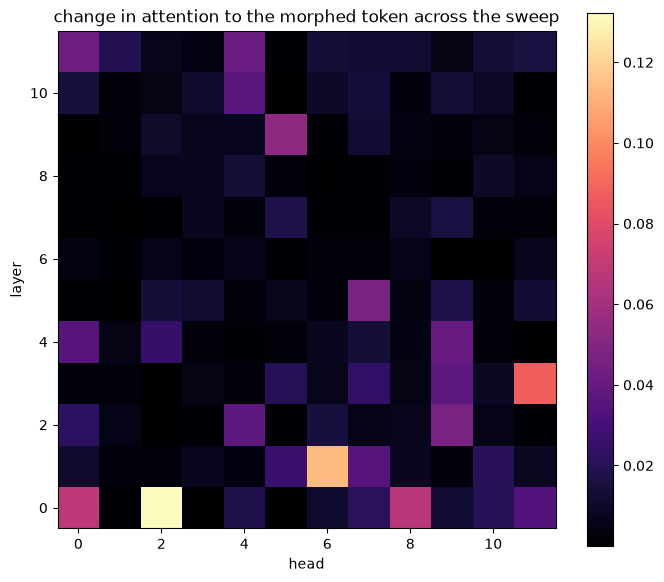

1. layer  0 head  2   moves 0.132
2. layer  1 head  6   moves 0.113
3. layer  3 head 11   moves 0.088


In [ ]:
@torch.no_grad()
def attention_sweep(phrase, changed_index, target_word, model_name="gpt2", n_steps=51, chunk=16):
    tokenizer, model = load(model_name)
    emb = model.get_input_embeddings()
    inputs = tokenizer(phrase, return_tensors="pt")
    ids, attn = inputs["input_ids"], inputs["attention_mask"]
    base = emb(ids).detach()
    v0 = base[0, changed_index, :].clone()
    v1 = emb.weight[tokenizer.encode(" " + target_word)[0]].detach().clone()

    alphas = torch.linspace(0, 1, n_steps)
    A = []
    for i in range(0, n_steps, chunk):
        a = alphas[i:i + chunk]
        n = len(a)
        E = base.repeat(n, 1, 1)
        E[:, changed_index, :] = (1 - a)[:, None] * v0 + a[:, None] * v1
        out = model(inputs_embeds=E, attention_mask=attn.repeat(n, 1), output_attentions=True)
        A.append(torch.stack(out.attentions, dim=1))   # (chunk, layer, head, seq, seq)
    A = torch.cat(A)
    return alphas, A[:, :, :, -1, changed_index]        # (alpha, layer, head)


alphas, look = attention_sweep("I love school because it's very", 1, "hate")
movement = (look.max(0).values - look.min(0).values)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(movement.numpy(), cmap="magma", origin="lower")
ax.set_xlabel("head"); ax.set_ylabel("layer")
ax.set_title("change in attention to the morphed token across the sweep")
fig.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

flat = movement.flatten()
for rank, idx in enumerate(flat.argsort(descending=True)[:3]):
    L, H = divmod(idx.item(), movement.shape[1])
    print(f"{rank + 1}. layer {L:2d} head {H:2d}   moves {flat[idx]:.3f}")

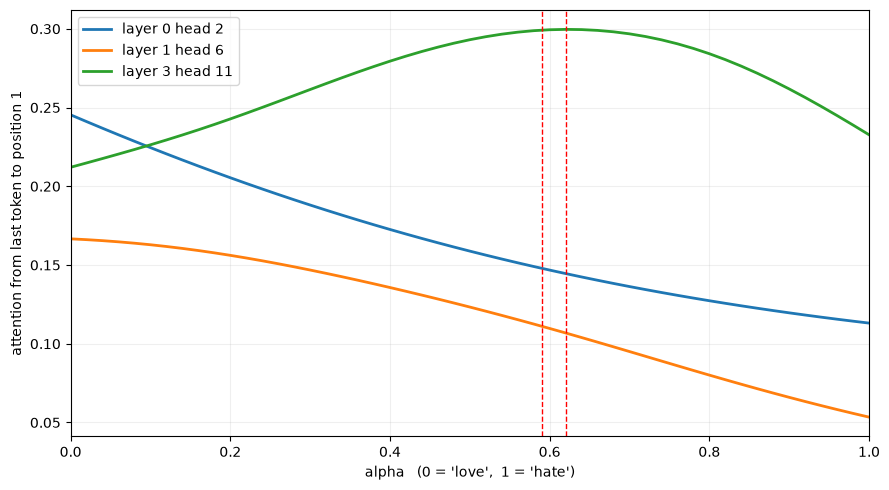

In [55]:
top = movement.flatten().argsort(descending=True)[:3]
fig, ax = plt.subplots(figsize=(9, 5))
for idx in top:
    L, H = divmod(idx.item(), movement.shape[1])
    ax.plot(alphas.numpy(), look[:, L, H].numpy(), lw=2, label=f"layer {L} head {H}")
for a, *_ in r1["transitions"]:
    ax.axvline(a, color="red", ls="--", lw=1)
ax.set_xlabel("alpha   (0 = 'love',  1 = 'hate')")
ax.set_ylabel("attention from last token to position 1")
ax.set_xlim(0, 1); ax.grid(alpha=0.2); ax.legend()
plt.tight_layout(); plt.show()

tokens: [(0, 'I'), (1, 'Ġlike'), (2, 'Ġpoop'), (3, ','), (4, 'Ġand'), (5, 'ĠI'), (6, 'Ġalways'), (7, 'Ġget'), (8, 'Ġit'), (9, 'Ġwith'), (10, 'Ġa'), (11, 'Ġside'), (12, 'Ġof')]

blindfolded: largest change in any token's probability across the whole sweep = 0.000e+00
  no attention path means alpha has no route to the output. Expect 0.0.

morphing 'poop' -> 'salad' at position 2
  attention intact: 0 transition(s)
  blindfolded:      [('me', 0.0213), ('a', 0.0198), (',', 0.0187), ("'", 0.0187), ('my', 0.0162)]
                    identical at all 101 alphas


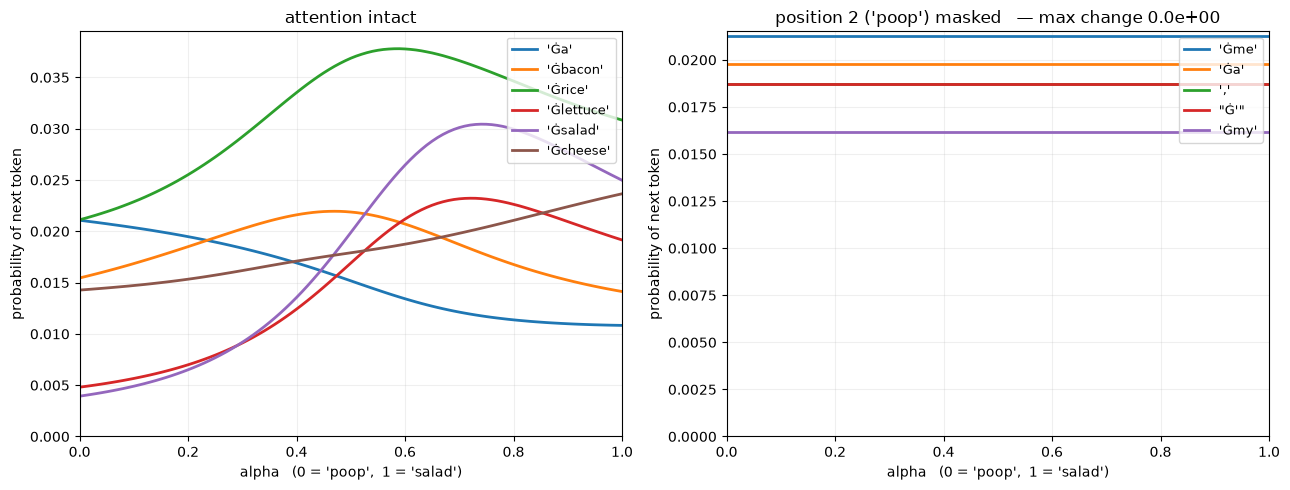

tokens: [(0, 'I'), (1, 'Ġlike'), (2, 'Ġpizza'), (3, ','), (4, 'Ġand'), (5, 'ĠI'), (6, 'Ġalways'), (7, 'Ġget'), (8, 'Ġit'), (9, 'Ġwith'), (10, 'Ġa'), (11, 'Ġside'), (12, 'Ġof')]

blindfolded: largest change in any token's probability across the whole sweep = 0.000e+00
  no attention path means alpha has no route to the output. Expect 0.0.

morphing 'pizza' -> 'x' at position 2
  attention intact: 3 transition(s)
    alpha=0.61  'cheese' -> 'a'
    alpha=0.65  'a' -> 'x'
    alpha=0.98  'x' -> 'a'
  blindfolded:      [('me', 0.0213), ('a', 0.0198), (',', 0.0187), ("'", 0.0187), ('my', 0.0162)]
                    identical at all 101 alphas


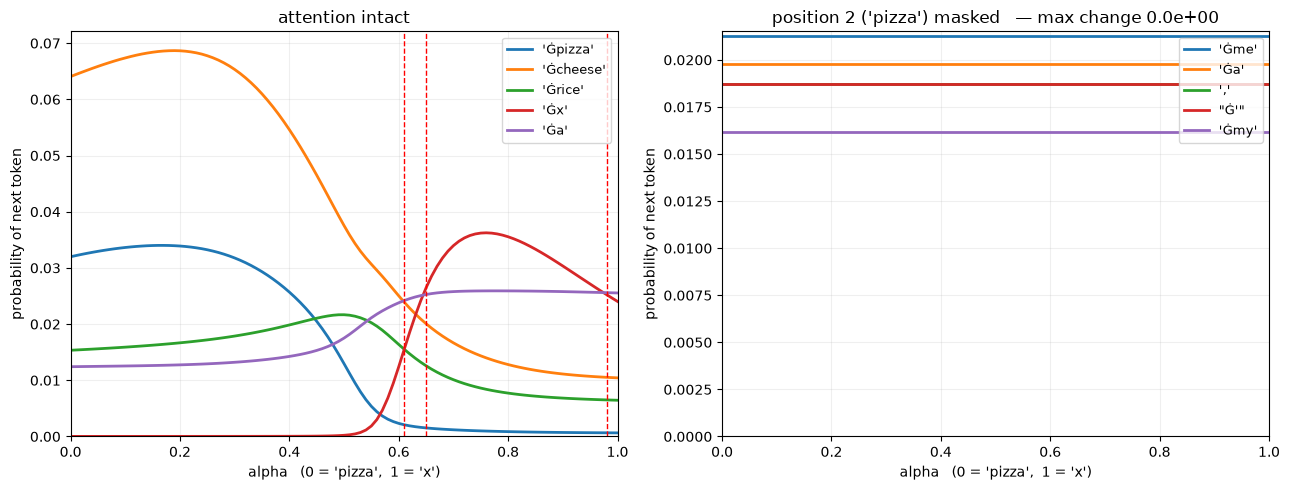

True
tensor(0.)


In [52]:
r_salad = nullify_attention("I like poop, and I always get it with a side of", 2, "salad")
r_x     = nullify_attention("I like pizza, and I always get it with a side of", 2, "x")

print(torch.equal(r_salad["P_blind"], r_x["P_blind"]))
print((r_salad["P_blind"] - r_x["P_blind"]).abs().max())

